# Convolutions 

## Problem Definition

The two properties an image model needs are **translation equivariance (the output shifts when the input shifts)** and **parameter sharing (the same feature detector runs everywhere)**. Dense layers give you neither. Convolution gives you both for free.

## Basic Concept

A 2D convolution takes a small weight matrix called the kernel (or filter), slides it across the input, and at each location computes the sum of element-wise products.

That one formula — **shared weights, locality, sliding window** — is the entire idea. Everything else is bookkeeping.

### Padding

Without padding, every convolution shrinks the feature map.
```
11111111      00000000
11111111  --> 0xxxxxx0
11111111      0xxxxxx0
11111111      00000000
```

Modes you meet in practice:
* zero (most common)
* reflect (mirror the edge, avoids hard borders in generative models)
* replicate (copy the edge)
* circular (wrap around, used in toroidal problems).

### Stride

Stride is the **step size of the slide.** stride=1 is the default. stride=2 halves the spatial dimensions and is the classic way to **downsample** inside a CNN without a separate pooling layer — every modern architecture (ResNet, ConvNeXt, MobileNet) uses strided convs in place of max-pool somewhere.

### Multiple input channels

Real images have three channels. **A 3x3 convolution on an RGB input is actually a 3x3x3 volume: one 3x3 slice per input channel.** At each spatial position, you multiply and sum across all three slices and add a bias.

### IM2COL

```
[1, 2, 3]     [0, 0, 0]
[4, 5, 6]  @  [0, 1, 0]
[7, 8, 9]     [0, 0, 0]
```
flatten to
```
[1, 2, 3, 4, 5, 6, 7, 8, 9] dot
[0, 0, 0, 0, 1, 0, 0, 0, 0]
```

#### Receptive Field

```
11111       00000       00000
11111  -->  01110 --->  00000
11111       01110       00100
11111       01110       00000
11111       00000       00000
```

The entire reason "3x3 all the way down" works (VGG, ResNet, ConvNeXt) is that **two 3x3 convs see the same input area as one 5x5 conv but with fewer parameters and an extra non-linearity in between**.



# Build your Own

In [24]:
import numpy as np

def pad2d(x, p):
    if p == 0:
        return x
    h, w = x.shape[-2:]
    out = np.zeros(x.shape[:-2] + (h + 2 * p, w + 2 * p), dtype=x.dtype)
    # Impressive dimension concatenation
    # print(x.shape[:-2])
    # print(h + 2 * p, w + 2 * p)
    # print((1, 2) + (3, 4))
    out[..., p:p+h, p:p+w] = x
    return out

x = np.arange(9).reshape(3, 3)
print(x)
print()
print(pad2d(x, 1))

[[0 1 2]
 [3 4 5]
 [6 7 8]]

[[0 0 0 0 0]
 [0 0 1 2 0]
 [0 3 4 5 0]
 [0 6 7 8 0]
 [0 0 0 0 0]]


In [25]:
def conv2d_naive(x, w, b=None, stride=1, padding=0):
    c_in, h, w_in = x.shape
    c_out, c_in_w, kh, kw = w.shape
    assert c_in == c_in_w

    x_pad = pad2d(x, padding)
    h_out = (h + 2 * padding - kh) // stride + 1
    w_out = (w_in + 2 * padding - kw) // stride + 1

    out = np.zeros((c_out, h_out, w_out), dtype=np.float32)
    for oc in range(c_out):
        for i in range(h_out):
            for j in range(w_out):
                hs = i * stride
                ws = j * stride
                patch = x_pad[:, hs:hs + kh, ws:ws + kw]
                out[oc, i, j] = np.sum(patch * w[oc])
        if b is not None:
            out[oc] += b[oc]
    return out

Text(0.5, 1.0, 'Sobel X')

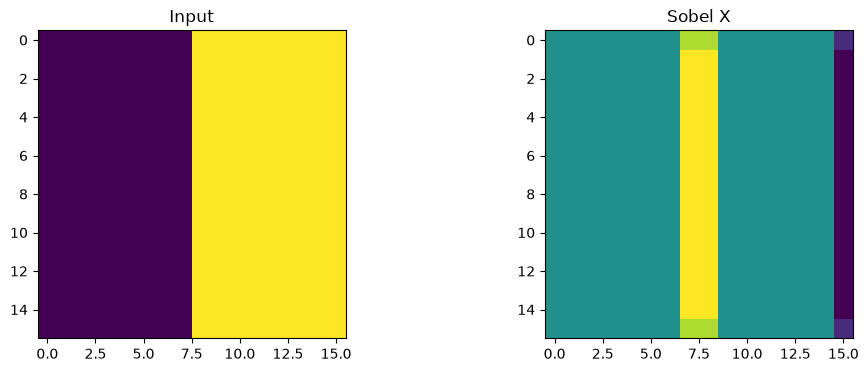

In [26]:
def synthetic_step_image():
    img = np.zeros((1, 16, 16), dtype=np.float32)
    img[:, :, 8:] = 1.0
    return img

sobel_x = np.array([
    [[-1, 0, 1],
     [-2, 0, 2],
     [-1, 0, 1]]
], dtype=np.float32)[None]

x = synthetic_step_image()
y = conv2d_naive(x, sobel_x, padding=1)

%matplotlib inline

import matplotlib.pyplot as plt

#print(x[0])
#print(y[0])
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].imshow(x[0])
axs[0].set_title("Input")

axs[1].imshow(y[0])
axs[1].set_title("Sobel X")

In [33]:
def im2col(x, kh, kw, stride=1, padding=0):
    c_in, h, w = x.shape
    x_pad = pad2d(x, padding)
    h_out = (h + 2 * padding - kh) // stride + 1
    w_out = (w + 2 * padding - kw) // stride + 1

    cols = np.zeros((c_in * kh * kw, h_out * w_out), dtype=x.dtype)
    col = 0
    for i in range(h_out):
        for j in range(w_out):
            hs = i * stride
            ws = j * stride
            patch = x_pad[:, hs:hs + kh, ws:ws + kw]
            cols[:, col] = patch.reshape(-1)
            col += 1
    return cols, h_out, w_out

def conv2d_im2col(x, w, b=None, stride=1, padding=0):
    c_out, c_in, kh, kw = w.shape
    cols, h_out, w_out = im2col(x, kh, kw, stride, padding)
    w_flat = w.reshape(c_out, -1)
    out = w_flat @ cols
    if b is not None:
        out += b[:, None]
    return out.reshape(c_out, h_out, w_out)

rng = np.random.default_rng(0)

x = rng.normal(0, 1, (3, 16, 16)).astype(np.float32)
w = rng.normal(0, 1, (8, 3, 3, 3)).astype(np.float32)
b = rng.normal(0, 1, (8,)).astype(np.float32)

y_naive = conv2d_naive(x, w, b, padding=1)
y_im2col = conv2d_im2col(x, w, b, padding=1)

#print(y_naive)
#print("="*40)
#print(y_im2col)
print(np.allclose(y_naive, y_im2col, rtol=1e-3, atol=1e-5))

print(f"Max abs diff: {np.max(y_naive - y_im2col):.2e}")


True
Max abs diff: 2.86e-06


In [ ]:
KERNELS = {
    "identity": np.array([
        [0, 0, 0],
        [0, 1, 0],
        [0, 0, 0]
    ], dtype=np.float32),
    "blur_3x3": np.ones((3, 3, 3, 3), dtype=np.float32) / 9,
    "sharpen": np.array([
        [0, -1, 0],
        [-1, 5, -1],
        [0, -1, 0]
    ], dtype=np.float32),
    "sobel_x": np.array([
        [[-1, 0, 1],
         [-2, 0, 2],
         [-1, 0, 1]]
    ], dtype=np.float32),
    "sobel_y": np.array([
        [[-1, -2, -1],
         [0, 0, 0],
         [1, 2, 1]]
    ], dtype=np.float32),
}

def apply_kernel(img2d, kernel):
    x = img2d[None].astype(np.float32)
    w = kernel[None, None]

    return conv2d_im2col(x, w, padding=1)[0]

## Illustration
%matplotlib inline
import matplotlib.pyplot as plt

# 合成测试图：左暗右亮 + 中心亮块，方便看出 blur / sharpen / sobel
h, w = 32, 48
img = np.zeros((h, w), dtype=np.float32)
img[:, w // 2 :] = 1.0
img[h // 4 : 3 * h // 4, w // 4 : 3 * w // 4] += 0.5
img = np.clip(img, 0, 1)

# apply_kernel 期望 2D kernel (Kh, Kw)
kernels_2d = {
    "identity": KERNELS["identity"],
    "blur_3x3": np.ones((3, 3), dtype=np.float32) / 9,
    "sharpen": KERNELS["sharpen"],
    "sobel_x": np.asarray(KERNELS["sobel_x"]).reshape(3, 3),
    "sobel_y": np.asarray(KERNELS["sobel_y"]).reshape(3, 3),
}

results = {"input": img}
for name, kernel in kernels_2d.items():
    out = apply_kernel(img, kernel)
    results[name] = out
    assert out.shape == img.shape, f"{name}: shape {out.shape} != {img.shape}"

assert np.allclose(results["identity"], img, atol=1e-5), "identity kernel failed"
print("All kernel smoke tests passed.")
for name, out in results.items():
    print(f"  {name:>10}: min={out.min():7.3f}, max={out.max():7.3f}")

fig, axs = plt.subplots(2, 3, figsize=(12, 7))
for ax, (name, out) in zip(axs.ravel(), results.items()):
    im = ax.imshow(out, cmap="gray")
    ax.set_title(name)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle("Convolution Kernels Illustration")
plt.tight_layout()
plt.show()

